In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, adjusted_rand_score, normalized_mutual_info_score, pairwise_distances
from sklearn.random_projection import GaussianRandomProjection
from scipy.optimize import linear_sum_assignment
from time import time
!pip -q install kneed
from kneed import KneeLocator

import sys
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Fashion-MNIST-unsupervised")
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.tool import (
    k_mean_classify,
    spectral_clustering
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load Fashion-MNIST from OpenML
# Classes (0-9): T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
X, y = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto", return_X_y=True)
y = y.astype(int)

print(type(X),X.shape)
print(type(y),y.shape)

<class 'numpy.ndarray'> (70000, 784)
<class 'numpy.ndarray'> (70000,)


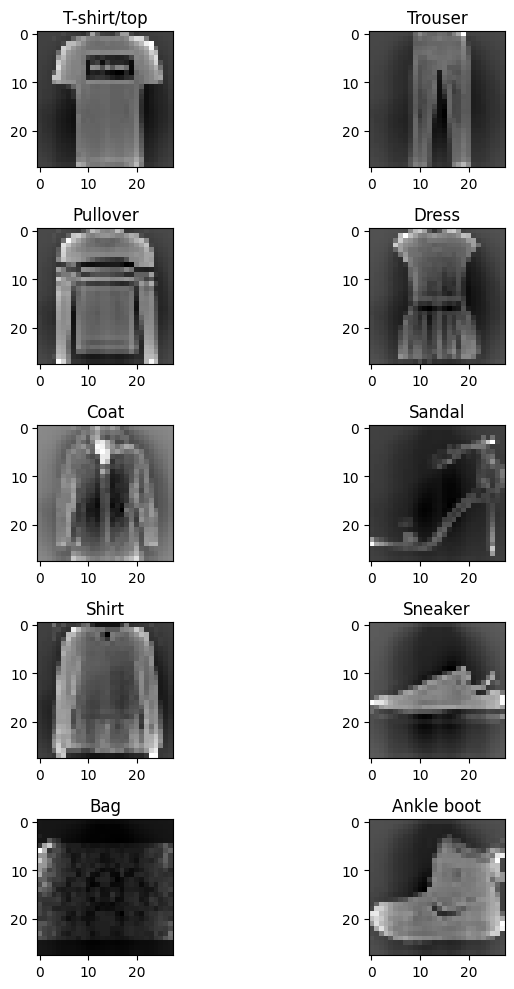

In [7]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, ax = plt.subplots(5,2,figsize=(8,10))
for i in range(5):
    for j in range(2):
        idx = np.where(y==2*i+j)[0][0]
        img = X[idx].reshape(28,28)
        ax[i,j].imshow(img, cmap="gray")
        ax[i,j].set_title(class_names[2*i+j])
plt.tight_layout()
plt.savefig(FIG_DIR / "example_images.png")
plt.show()

In [5]:
# Standardize

scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(X)

Number of components to retain >=95% variance:  256
Number of components to retain >=90% variance:  137
Elbow point (best n_components): 96
Best cumulative_variance_ratio : 0.8677868253677322


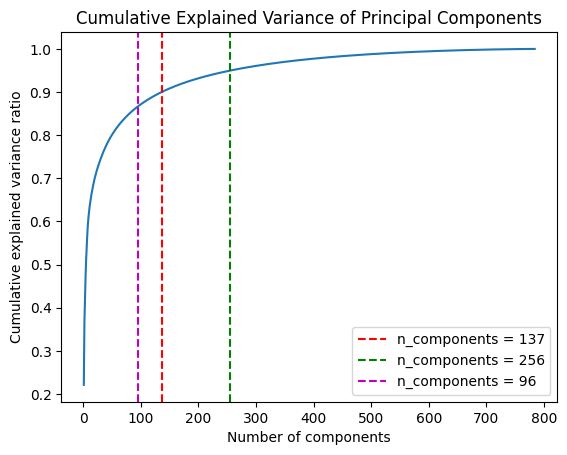

In [6]:
# Dimensionality reduction - PCA
pca = PCA()
pca.fit_transform(X)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

n_component_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print("Number of components to retain >=95% variance: ", n_component_95)
n_component_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
print("Number of components to retain >=90% variance: ", n_component_90)

knee = KneeLocator(range(1, 785),
                   cumulative_variance_ratio,
                   curve='concave', direction='increasing')
print("Elbow point (best n_components):", knee.knee)
print("Best cumulative_variance_ratio :", knee.knee_y)

plt.plot(np.arange(1,785), cumulative_variance_ratio)
plt.axvline(x=n_component_90-1, color='r', linestyle='--', label=f'n_components = {n_component_90}')
plt.axvline(x=n_component_95-1, color='g', linestyle='--', label=f'n_components = {n_component_95}')
plt.axvline(x=knee.knee-1, color='m', linestyle='--', label=f'n_components = {knee.knee}')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.legend()
plt.title("Cumulative Explained Variance of Principal Components")
plt.savefig(FIG_DIR / "cumulative_explained_variance_ratio.png")
plt.show()

,dim,corr_pca,corr_rp
0,10,0.897230,0.813865
1,20,0.960885,0.887804
2,50,0.986736,0.957982
3,100,0.995733,0.977351
4,200,0.999039,0.984931
5,300,0.999736,0.990451


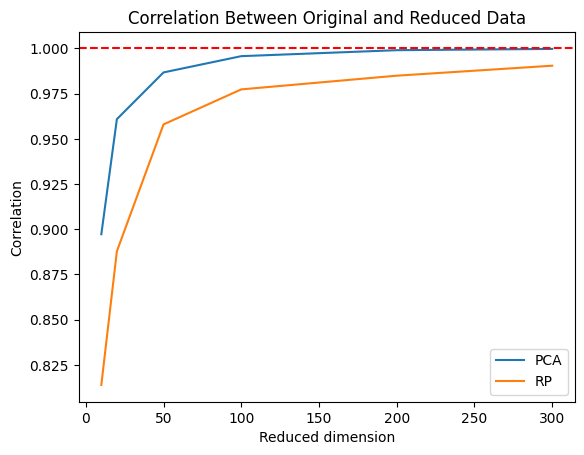

In [8]:
# Dimensionality reduction - Random Projection
n = 3000
np.random.seed(42)
X_sub = X[np.random.choice(len(X), n, replace=False)]

upperTriangle = np.triu_indices(n, k=1)
D = pairwise_distances(X_sub)[upperTriangle]

dims = [10, 20, 50, 100, 200, 300]
corr_pca = []
corr_rp = []
for dim in dims:
    pca = PCA(n_components=dim, random_state = 42)
    X_pca = pca.fit_transform(X_sub)
    D_pca = pairwise_distances(X_pca)[upperTriangle]
    corr_pca.append(np.corrcoef(D, D_pca)[0,1])

for dim in dims:
    rp = GaussianRandomProjection(n_components=dim, random_state = 42)
    X_rp = rp.fit_transform(X_sub)
    D_rp = pairwise_distances(X_rp)[upperTriangle]
    corr_rp.append(np.corrcoef(D, D_rp)[0,1])

corr_df = pd.DataFrame({"dim": dims, "corr_pca": corr_pca, "corr_rp": corr_rp})
display(corr_df)
corr_df.to_csv(RESULTS_DIR / "Correlation between original and reduced data.csv", index=False)

# Make a plot of this correlation vs. dim for the two methods.
plt.plot(dims, corr_pca, label="PCA")
plt.plot(dims, corr_rp, label="RP")
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel("Reduced dimension")
plt.ylabel("Correlation")
plt.legend()
plt.title("Correlation Between Original and Reduced Data")
plt.savefig(FIG_DIR / "correlation_between_original_and_reduced_data.png")
plt.show()

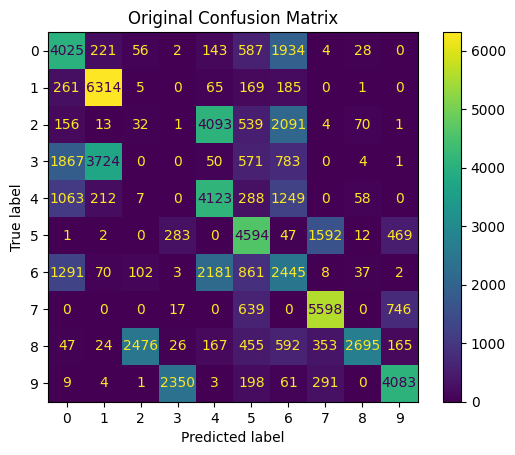

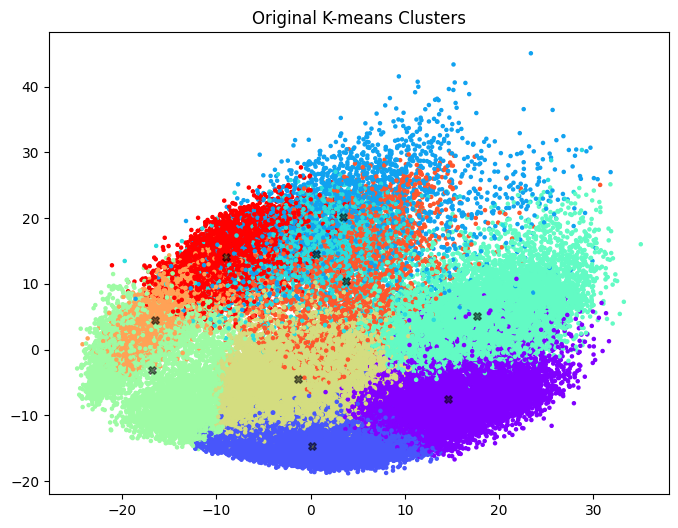

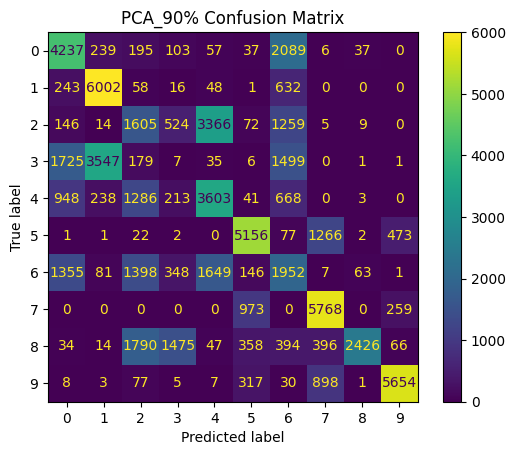

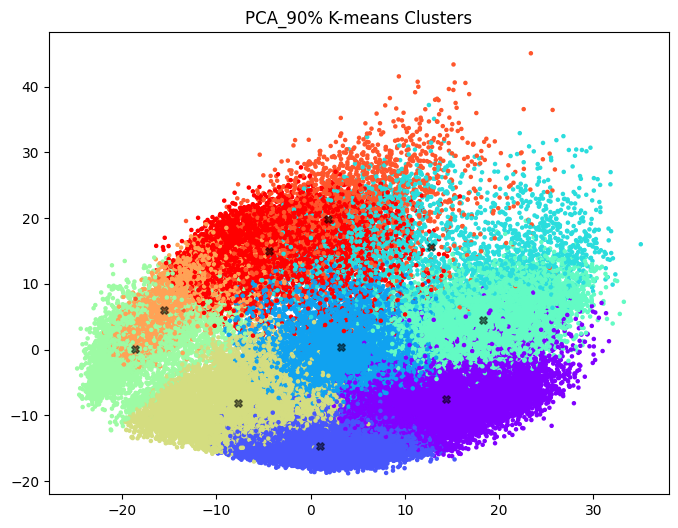

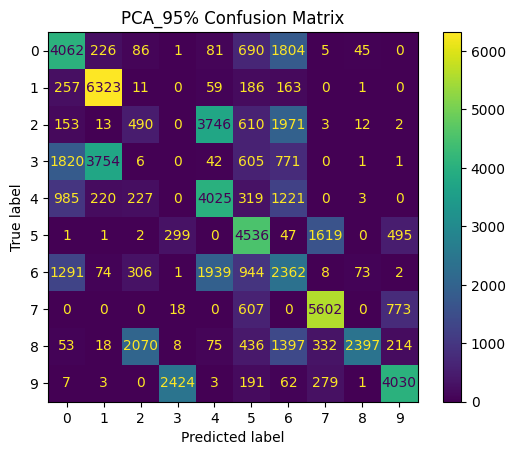

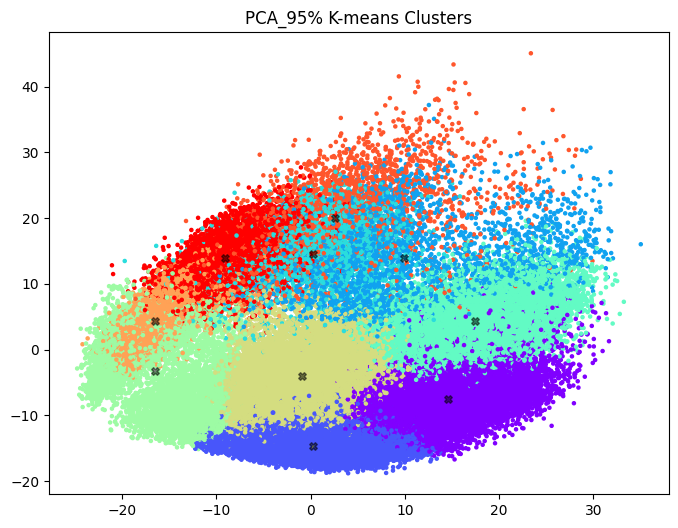

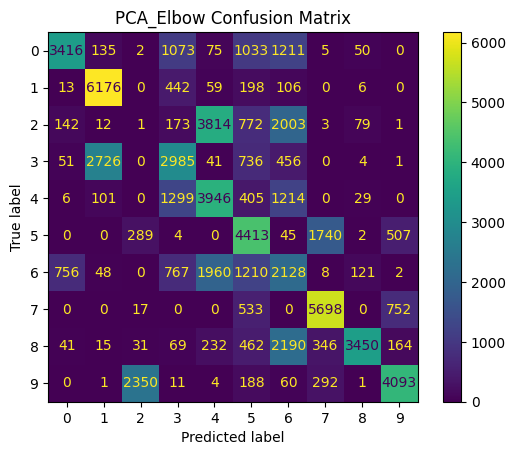

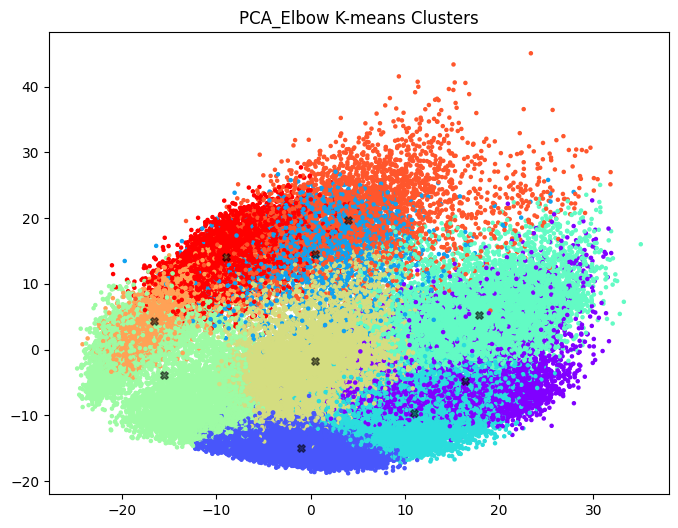

In [9]:
pca_list = [
    ("Original", None),
    ("PCA_90%", PCA(n_components=n_component_90)),
    ("PCA_95%", PCA(n_components=n_component_95)),
    ("PCA_Elbow", PCA(n_components=knee.knee))
]

results_df = k_mean_classify(pca_list, X, y, FIG_DIR)
results_df.to_csv(RESULTS_DIR / "results.csv", index=False)

In [10]:
results_df

,name,accuracy,ari,nmi,inertia,time
0,Original,0.484414,0.348205,0.504975,3.050882e+07,24.151339
1,PCA_90%,0.520143,0.368910,0.506765,2.543789e+07,4.670432
2,PCA_95%,0.483243,0.335537,0.488861,2.779011e+07,8.826572
3,PCA_Elbow,0.518657,0.341162,0.495981,2.338318e+07,3.356735


In [16]:
# spectral clustering

n_sc = 5000
np.random.seed(42)
indices_sc = np.random.choice(len(X), n_sc, replace=False)
X_sub_sc = X[indices_sc]
y_sub_sc = y[indices_sc]

results_kmeans_df = k_mean_classify(pca_list, X_sub_sc, y_sub_sc, FIG_DIR)
results_sc_df = spectral_clustering(pca_list, X_sub_sc, y_sub_sc, FIG_DIR)
results_sub_df = pd.concat([results_kmeans_df, results_sc_df], ignore_index=True)
results_sub_df.to_csv(RESULTS_DIR / "results_k-means_vs_spectral_clustering.csv", index=False)

Output hidden; open in https://colab.research.google.com to view.

In [17]:
results_sub_df

,name,accuracy,ari,nmi,inertia,time
0,Original,0.5634,0.353399,0.490992,2.165277e+06,2.864444
1,PCA_90%,0.5062,0.332117,0.481472,1.801990e+06,3.027569
2,PCA_95%,0.4886,0.349744,0.507666,2.000078e+06,3.820733
3,PCA_Elbow,0.5532,0.352830,0.490485,1.682231e+06,1.350585
4,Original,0.5830,0.410127,0.585751,NaN,2.934989
5,PCA_90%,0.5846,0.415732,0.591234,NaN,5.621796
6,PCA_95%,0.5840,0.421487,0.593905,NaN,4.265791
7,PCA_Elbow,0.5860,0.427316,0.603007,NaN,5.209295
